In [1]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
import pandas as pd
from QAESimulator import QAEAnalyticDistFunc
from MLEUtil import FindAmpSqMLE, FindAmpSqMLERandom

In [2]:
np.random.seed(1)

In [3]:
ampSqTrue = 0.3
nShot = 2 ** 4
nGroverMax = 2 ** 12
nEstim = 500

In [4]:
# 探索するthetaの値
thetaTrue = np.arcsin(np.sqrt(ampSqTrue))
delTheta = 0.001
numTheta = 200000
thetas = np.linspace(thetaTrue - delTheta, thetaTrue + delTheta, num=numTheta)

In [5]:
for iSeq in range(2, 9):
    print("iSeq " + str(iSeq))
    estims = []
    n1Mat = []
    for i in range(nEstim):
        if i % 10 == 0 : print(str(i) + ': ' + datetime.datetime.now().strftime('%Y/%m/%d %H:%M:%S'))
        nGrovers, n1s = QAEAnalyticDistFunc(ampSqTrue, nShot, nGroverMax)
        n1Mat += [n1s]
        #estims += [FindAmpSqMLE(nGrovers, n1s, nShot, thetas=thetas)]
        estims += [FindAmpSqMLERandom(nGrovers, n1s, nShot, thetaTrue - delTheta, thetaTrue + delTheta, numTheta)]
        
    errors = np.array(estims) - ampSqTrue
    errorSums = errors.cumsum()
    outDf = pd.DataFrame({"Id":np.arange(nEstim), "Estim":estims, "Err":errors, "ErrSum":errorSums})

    filename = "errorSum_ampSqTure=" + str(ampSqTrue) + "_seq" + str(iSeq) + "_" + datetime.datetime.now().strftime('%Y%m%d%H%M%S') + ".csv"
    np.savetxt(filename, outDf, delimiter=',')

seed 2
0: 2023/08/08 17:18:30
10: 2023/08/08 17:20:58
20: 2023/08/08 17:23:24
30: 2023/08/08 17:25:53
40: 2023/08/08 17:28:22
50: 2023/08/08 17:30:50
60: 2023/08/08 17:33:17
70: 2023/08/08 17:35:47
80: 2023/08/08 17:38:15
90: 2023/08/08 17:40:43
100: 2023/08/08 17:43:12
110: 2023/08/08 17:45:44
120: 2023/08/08 17:48:12
130: 2023/08/08 17:50:47
140: 2023/08/08 17:53:25
150: 2023/08/08 17:55:52
160: 2023/08/08 17:58:22
170: 2023/08/08 18:00:40
180: 2023/08/08 18:03:06
190: 2023/08/08 18:05:32
200: 2023/08/08 18:07:59
210: 2023/08/08 18:10:26
220: 2023/08/08 18:12:52
230: 2023/08/08 18:15:18
240: 2023/08/08 18:17:48
250: 2023/08/08 18:20:15
260: 2023/08/08 18:22:42
270: 2023/08/08 18:25:09
280: 2023/08/08 18:27:36
290: 2023/08/08 18:30:02
300: 2023/08/08 18:32:28


C:\Users\koich\Desktop\Code\QAEErrorVsNShotNGrover\MLEUtil.py:9: RuntimeWarning: divide by zero encountered in log
  ret += n1 * np.log(p) + (nShot - n1) * np.log(1.0 - p)


310: 2023/08/08 18:34:57
320: 2023/08/08 18:37:22
330: 2023/08/08 18:39:47
340: 2023/08/08 18:42:12
350: 2023/08/08 18:44:37
360: 2023/08/08 18:47:02
370: 2023/08/08 18:49:26
380: 2023/08/08 18:51:50
390: 2023/08/08 18:54:15
400: 2023/08/08 18:56:39
410: 2023/08/08 18:59:01
420: 2023/08/08 19:01:26
430: 2023/08/08 19:03:50
440: 2023/08/08 19:06:13
450: 2023/08/08 19:08:36
460: 2023/08/08 19:11:02
470: 2023/08/08 19:13:26
480: 2023/08/08 19:15:52
490: 2023/08/08 19:18:17
seed 3
0: 2023/08/08 19:20:41
10: 2023/08/08 19:23:06
20: 2023/08/08 19:25:31
30: 2023/08/08 19:27:55
40: 2023/08/08 19:30:20
50: 2023/08/08 19:32:46
60: 2023/08/08 19:35:10
70: 2023/08/08 19:37:35
80: 2023/08/08 19:40:00
90: 2023/08/08 19:42:25
100: 2023/08/08 19:44:49
110: 2023/08/08 19:47:13
120: 2023/08/08 19:49:38
130: 2023/08/08 19:52:03
140: 2023/08/08 19:54:28
150: 2023/08/08 19:56:52
160: 2023/08/08 19:59:14
170: 2023/08/08 20:01:39
180: 2023/08/08 20:04:04
190: 2023/08/08 20:06:28
200: 2023/08/08 20:08:53
210:

In [15]:
errDf1 = pd.read_csv('C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230808_ManyEstimSum/errorSum_ampSqTure=0.3_seq1_20230808192041.csv', header=None)
errDf2 = pd.read_csv('C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230808_ManyEstimSum/errorSum_ampSqTure=0.3_seq2_20230808212145.csv', header=None)
errDf3 = pd.read_csv('C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230808_ManyEstimSum/errorSum_ampSqTure=0.3_seq3_20230808232358.csv', header=None)
errDf4 = pd.read_csv('C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230808_ManyEstimSum/errorSum_ampSqTure=0.3_seq4_20230809012557.csv', header=None)
errDf5 = pd.read_csv('C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230808_ManyEstimSum/errorSum_ampSqTure=0.3_seq5_20230809032754.csv', header=None)
errDf6 = pd.read_csv('C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230808_ManyEstimSum/errorSum_ampSqTure=0.3_seq6_20230809052954.csv', header=None)
errDf7 = pd.read_csv('C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230808_ManyEstimSum/errorSum_ampSqTure=0.3_seq7_20230809073133.csv', header=None)

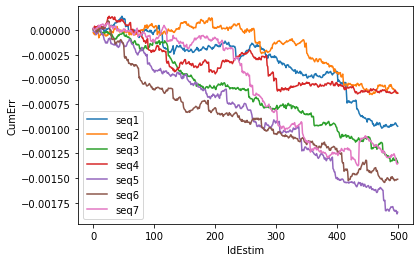

In [18]:
plt.xlabel('IdEstim')
plt.ylabel('CumErr')

# 描画
ax = plt.gca()
plt.plot(np.arange(len(errDf1.index)), errDf1.iloc[:,3], label="seq1")
plt.plot(np.arange(len(errDf2.index)), errDf2.iloc[:,3], label="seq2")
plt.plot(np.arange(len(errDf3.index)), errDf3.iloc[:,3], label="seq3")
plt.plot(np.arange(len(errDf4.index)), errDf4.iloc[:,3], label="seq4")
plt.plot(np.arange(len(errDf5.index)), errDf5.iloc[:,3], label="seq5")
plt.plot(np.arange(len(errDf6.index)), errDf6.iloc[:,3], label="seq6")
plt.plot(np.arange(len(errDf7.index)), errDf7.iloc[:,3], label="seq7")

ax.legend()
plt.show()